<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 3, El audio como serie de tiempo**

Importamos las librerías necesarias

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import urllib.request
from scipy.io import wavfile
from IPython.display import Audio, display

Fijamos las semillas para que los resultados sean reproducibles

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

Descargamos la grabación real (silbato de tren) desde GitHub

In [ ]:
URL = "https://raw.githubusercontent.com/pytorch/audio/main/test/torchaudio_unittest/assets/steam-train-whistle-daniel_simon.wav"
urllib.request.urlretrieve(URL, "tren.wav")

('tren.wav', <http.client.HTTPMessage at 0x79718c708e00>)

Leemos el archivo wav: obtenemos el sample rate y la forma de onda

In [ ]:
sr, w = wavfile.read("tren.wav")

Convertimos de estéreo (2 canales) a mono (1 canal) promediando los dos canales

In [ ]:
audio = w.mean(axis=1).astype(np.float32)

Submuestreamos por 4 para aligerar el cómputo (44,100 Hz a 11,025 Hz)

In [ ]:
# Donde sr es Sampling Rate (frecuencia de muestreo)
audio = audio[::4]
sr = sr // 4

Normalizamos la amplitud al rango [-1, 1]

In [ ]:
audio = audio / np.abs(audio).max()

Mostramos las dimensiones de nuestra serie de tiempo

In [ ]:
print(f"sample rate: {sr} Hz , duración: {len(audio)/sr:.1f} s , observaciones: {len(audio):,d}")

sample rate: 11025 Hz , duración: 6.3 s , observaciones: 69,215


Graficamos la serie a dos escalas: la envolvente completa y 36 ms de oscilación

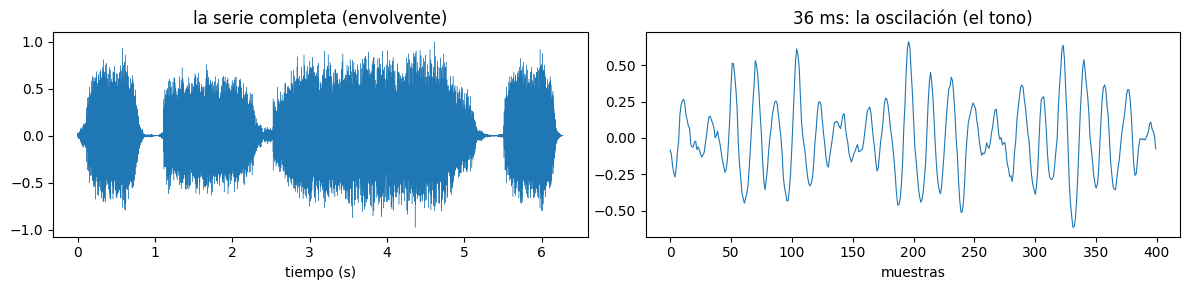

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(np.arange(len(audio)) / sr, audio, lw=0.3)
ax[0].set_title("la serie completa (envolvente)")
ax[0].set_xlabel("tiempo (s)")
ax[1].plot(audio[int(1.5*sr) : int(1.5*sr) + 400], lw=0.8)
ax[1].set_title("36 ms: la oscilación (el tono)")
ax[1].set_xlabel("muestras")
plt.tight_layout()
plt.show()

Escuchamos el audio

In [ ]:
display(Audio(audio, rate=sr))

Definimos la longitud de la ventana (L) y el horizonte (H)

In [ ]:
L = 160 # 160 muestras aprox 15 ms de contexto
H = 1  # predecimos la siguiente muestra

Realizamos el split temporal antes de construir ventanas: pasado = train, futuro = test

In [ ]:
n_tr = int(len(audio) * 0.8)

Construimos las ventanas de entrenamiento con un ciclo (stride=4 para controlar el solapamiento)

In [ ]:
X_tr, y_tr = [], []
for i in range(0, n_tr - L - H + 1, 4):
    X_tr.append(audio[i : i + L])  # la ventana: L muestras de pasado
    y_tr.append(audio[i + L : i + L + H])  # el target: la muestra siguiente

Construimos las ventanas de test (el input puede ver el final del train, el target no)

In [ ]:
X_te, y_te = [], []
for i in range(n_tr - L, len(audio) - L - H + 1, 4):
    X_te.append(audio[i : i + L])
    y_te.append(audio[i + L : i + L + H])

Convertimos las listas a tensores 3D con forma (n_ventanas, L, 1)

In [ ]:
X_tr = torch.tensor(np.array(X_tr)).unsqueeze(-1)
y_tr = torch.tensor(np.array(y_tr))
X_te = torch.tensor(np.array(X_te)).unsqueeze(-1)
y_te = torch.tensor(np.array(y_te))

Verificamos las dimensiones: pasamos de 2D (tabla) a 3D (secuencias)

In [ ]:
print("train:", X_tr.shape, ", test:", X_te.shape)

train: torch.Size([13803, 160, 1]) , test: torch.Size([3461, 160, 1])


Calculamos el baseline naive: la siguiente muestra = la muestra actual

In [ ]:
naive = ((X_te[:, -1, 0:1] - y_te)**2).mean().sqrt().item()
print(f"baseline naive: RMSE = {naive:.4f}")

baseline naive: RMSE = 0.0796
